# Debug: Topological Ordering in `AsymmetricShapley._sample_topological_ordering`

**Goal:** Verify whether the sampled orderings are *source-first* (ancestors on the left) or *sink-first* (ancestors on the right), and catch any causal-order violations.

We use two DAGs:
1. A tiny hand-crafted chain/fork so ground truth is obvious.
2. The Sachs **true** adjacency matrix (10 X-features + Y) — a real small DAG.

## 1. Setup & Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from itertools import permutations

sys.path.insert(0, "..")          # repo root
from explainability_models.shapley_values import AsymmetricShapley
from sklearn.linear_model import LinearRegression

SEED = 42
np.random.seed(SEED)
print("Imports OK")

Imports OK


/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Define Small Debug DAGs

We define two DAGs to compare against:
- **Chain + fork** (5 nodes): X0→X1→X2→Y, X0→X2  (manual, easy to reason about)
- **Sachs true DAG** (10 X + Y): loaded from file

For the chain+fork, valid topological orderings of X-features must always have X0 before X1, X0 before X2, X1 before X2.

In [2]:
# ── TINY DAG: X0 → X1 → X2 → Y,  X0 → X2  (4 nodes total, last = Y at idx 3)
# adj[i,j] = 1 means i → j
tiny_dag = np.array([
    # X0  X1  X2  Y
    [  0,  1,  1,  0],   # X0 → X1, X0 → X2
    [  0,  0,  1,  1],   # X1 → X2, X1 → Y
    [  0,  0,  0,  1],   # X2 → Y
    [  0,  0,  0,  0],   # Y (sink)
], dtype=int)

TINY_FEATURES = ["X0", "X1", "X2"]   # indices 0,1,2; Y is index 3

# Expected X-only edges:  X0→X1, X0→X2, X1→X2
# Valid topological orderings of {X0,X1,X2}: only [X0,X1,X2] = [0,1,2]
#  because X0 must come before both X1 and X2, and X1 must come before X2
valid_tiny_orderings = []
for perm in permutations([0, 1, 2]):
    ok = True
    for (i, j) in [(0,1), (0,2), (1,2)]:  # X-only edges
        if perm.index(i) > perm.index(j):
            ok = False
            break
    if ok:
        valid_tiny_orderings.append(list(perm))

print("Tiny DAG adjacency (incl. Y):")
print(tiny_dag)
print(f"\nValid topological orderings of X-features: {valid_tiny_orderings}")
print("(Only 1 valid ordering because it's a total order)")

# ── SACHS TRUE DAG (10 X + Y) ────────────────────────────────────────────────
sachs_adj = np.load("../data/causal/sachs_true_full_adjacency.npy")
SACHS_FEATURES = ["raf", "mek", "plc", "pip2", "pip3", "erk", "pka", "pkc", "p38", "jnk"]
# Y is at index 10

print("\nSachs adjacency shape:", sachs_adj.shape)
print("Sachs X-only edges (i→j, excluding Y):")
for i in range(10):
    for j in range(10):
        if sachs_adj[i, j]:
            print(f"  {SACHS_FEATURES[i]}({i}) → {SACHS_FEATURES[j]}({j})")

Tiny DAG adjacency (incl. Y):
[[0 1 1 0]
 [0 0 1 1]
 [0 0 0 1]
 [0 0 0 0]]

Valid topological orderings of X-features: [[0, 1, 2]]
(Only 1 valid ordering because it's a total order)

Sachs adjacency shape: (11, 11)
Sachs X-only edges (i→j, excluding Y):
  raf(0) → mek(1)
  mek(1) → erk(5)
  plc(2) → pip2(3)
  plc(2) → pip3(4)
  pip2(3) → pkc(7)
  pip3(4) → pip2(3)
  pka(6) → raf(0)
  pka(6) → mek(1)
  pka(6) → erk(5)
  pka(6) → p38(8)
  pka(6) → jnk(9)
  pkc(7) → raf(0)
  pkc(7) → mek(1)
  pkc(7) → p38(8)
  pkc(7) → jnk(9)


## 3. Initialize `AsymmetricShapley` Objects

We use a dummy `LinearRegression` model (weights don't matter — we only call `_sample_topological_ordering`, which doesn't use the model at all).

In [3]:
def make_dummy_explainer(dag, feature_names, seed=SEED):
    """Build an AsymmetricShapley with a trivial model — only used to test ordering."""
    n_x = len(feature_names)
    bg = pd.DataFrame(np.random.randn(50, n_x), columns=feature_names)
    model = LinearRegression()
    model.fit(bg, np.random.randn(50))   # random fit, predictions don't matter here
    return AsymmetricShapley(model, bg, dag, n_samples=200, random_state=seed)


# ── Tiny explainer ────────────────────────────────────────────────────────────
tiny_exp = make_dummy_explainer(tiny_dag, TINY_FEATURES)

print("=== Tiny DAG internals ===")
print(f"n_features      : {tiny_exp.n_features}")
print(f"_x_in_degree    : {tiny_exp._x_in_degree}")
print(f"_x_children     : {tiny_exp._x_children}")
print(f"  (X0 should have children [X1, X2]; X1 should have child [X2]; X2 no children)")

# ── Sachs explainer ───────────────────────────────────────────────────────────
sachs_train = pd.read_parquet("../data/processed/sachs_train.parquet")
X_sachs_bg = sachs_train[SACHS_FEATURES].sample(100, random_state=SEED)
sachs_model = LinearRegression()
sachs_model.fit(X_sachs_bg, sachs_train["Y"].sample(100, random_state=SEED))
sachs_exp = AsymmetricShapley(sachs_model, X_sachs_bg, sachs_adj, n_samples=200, random_state=SEED)

print("\n=== Sachs DAG internals ===")
print(f"n_features   : {sachs_exp.n_features}")
print(f"_x_in_degree : {sachs_exp._x_in_degree}")
print("  (pka=6 and plc=2 should be 0; raf=0, mek=1 should be > 0)")
source_nodes = [i for i, d in enumerate(sachs_exp._x_in_degree) if d == 0]
sink_adj_nodes = [i for i, d in enumerate(sachs_exp._x_in_degree) if d > 0]
print(f"Source nodes (in-degree 0): {[(i, SACHS_FEATURES[i]) for i in source_nodes]}")
print(f"Children map (non-empty):   {{ {', '.join(f'{SACHS_FEATURES[i]}({i}):{sachs_exp._x_children[i]}' for i in range(10) if sachs_exp._x_children[i])} }}")

=== Tiny DAG internals ===
n_features      : 3
_x_in_degree    : [0, 1, 2]
_x_children     : {0: [1, 2], 1: [2], 2: []}
  (X0 should have children [X1, X2]; X1 should have child [X2]; X2 no children)

=== Sachs DAG internals ===
n_features   : 10
_x_in_degree : [2, 3, 0, 2, 1, 2, 0, 1, 2, 2]
  (pka=6 and plc=2 should be 0; raf=0, mek=1 should be > 0)
Source nodes (in-degree 0): [(2, 'plc'), (6, 'pka')]
Children map (non-empty):   { raf(0):[1], mek(1):[5], plc(2):[3, 4], pip2(3):[7], pip3(4):[3], pka(6):[0, 1, 5, 8, 9], pkc(7):[0, 1, 8, 9] }


## 4. Sample & Inspect Orderings (Raw Printout)

Call `_sample_topological_ordering()` 200 times and print the first 20 results.

**Read left-to-right**: the leftmost element is the *first* feature added to the coalition (position 0). If ordering is correct, sources should appear **on the left**.

In [4]:
N_SAMPLES = 200

def sample_orderings(explainer, n):
    return [explainer._sample_topological_ordering() for _ in range(n)]


# ── Tiny DAG ──────────────────────────────────────────────────────────────────
tiny_orderings = sample_orderings(tiny_exp, N_SAMPLES)

print("=== TINY DAG — first 20 sampled orderings (index = position in ordering) ===")
print(f"Features: {TINY_FEATURES}  (expected source: X0=0)\n")
print(f"{'#':>3}  {'ordering (indices)':25}  named")
for k, o in enumerate(tiny_orderings[:20]):
    named = " → ".join(TINY_FEATURES[i] for i in o)
    print(f"{k:>3}  {str(o):25}  {named}")

# ── Sachs DAG ─────────────────────────────────────────────────────────────────
sachs_orderings = sample_orderings(sachs_exp, N_SAMPLES)

print("\n=== SACHS DAG — first 20 sampled orderings ===")
print(f"Known sources (in-degree 0): pka(6), plc(2)\n")
print(f"{'#':>3}  {'indices':35}  named")
for k, o in enumerate(sachs_orderings[:20]):
    named = " → ".join(SACHS_FEATURES[i] for i in o)
    print(f"{k:>3}  {str(o):35}  {named}")

=== TINY DAG — first 20 sampled orderings (index = position in ordering) ===
Features: ['X0', 'X1', 'X2']  (expected source: X0=0)

  #  ordering (indices)         named
  0  [0, 1, 2]                  X0 → X1 → X2
  1  [0, 1, 2]                  X0 → X1 → X2
  2  [0, 1, 2]                  X0 → X1 → X2
  3  [0, 1, 2]                  X0 → X1 → X2
  4  [0, 1, 2]                  X0 → X1 → X2
  5  [0, 1, 2]                  X0 → X1 → X2
  6  [0, 1, 2]                  X0 → X1 → X2
  7  [0, 1, 2]                  X0 → X1 → X2
  8  [0, 1, 2]                  X0 → X1 → X2
  9  [0, 1, 2]                  X0 → X1 → X2
 10  [0, 1, 2]                  X0 → X1 → X2
 11  [0, 1, 2]                  X0 → X1 → X2
 12  [0, 1, 2]                  X0 → X1 → X2
 13  [0, 1, 2]                  X0 → X1 → X2
 14  [0, 1, 2]                  X0 → X1 → X2
 15  [0, 1, 2]                  X0 → X1 → X2
 16  [0, 1, 2]                  X0 → X1 → X2
 17  [0, 1, 2]                  X0 → X1 → X2
 18  [0, 1, 2]      

## 5. Visualize DAG Structure

Draw both DAGs with a hierarchical left-to-right layout. Node labels include the in-degree so it's easy to spot sources (in-degree = 0).

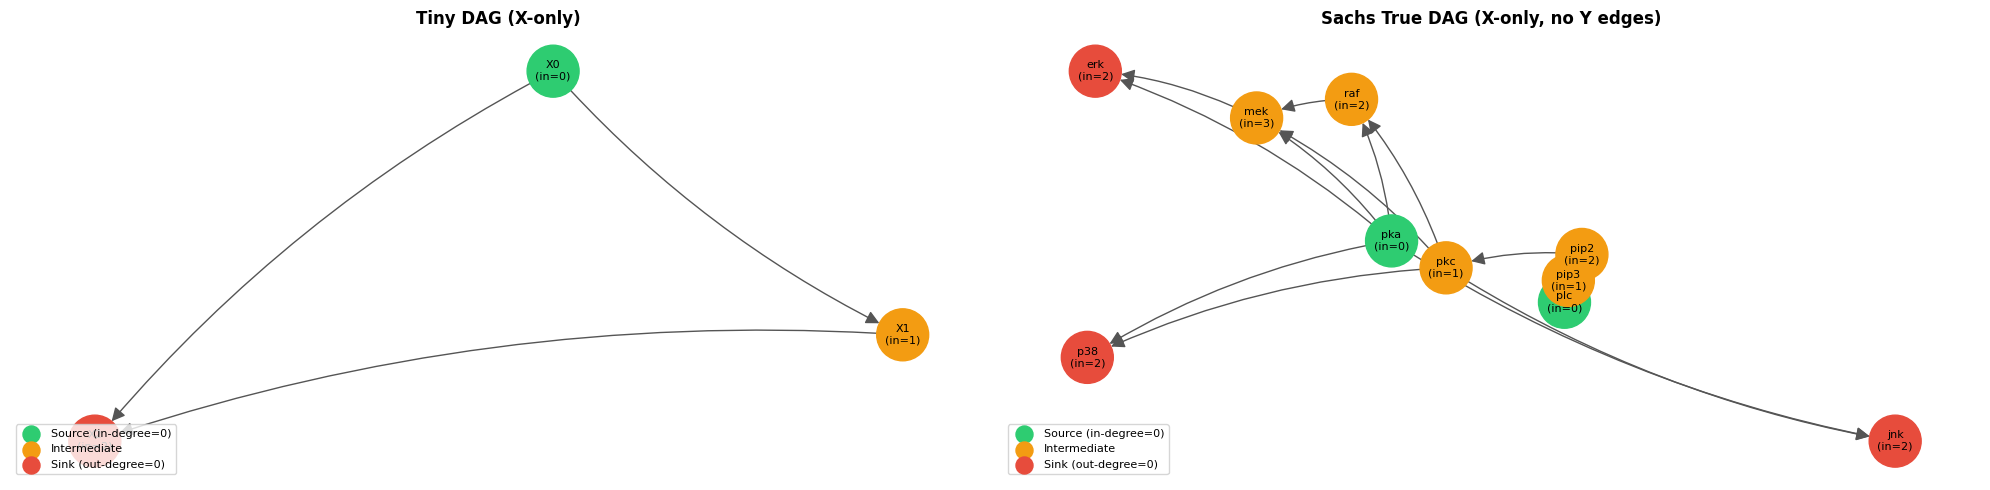


Expected left-to-right direction: SOURCE nodes on the LEFT → SINK nodes on the RIGHT
A valid topological ordering should list nodes roughly left to right in this graph.


In [5]:
def draw_dag(adj, feature_names, title, explainer=None, ax=None):
    """Draw DAG (X-only subgraph) with hierarchical layout. 
    Nodes coloured by in-degree: green=source, orange=intermediate, red=sink."""
    n = len(feature_names)
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(n):
            if adj[i, j]:
                G.add_edge(i, j)

    in_deg = [G.in_degree(i) for i in range(n)]
    out_deg = [G.out_degree(i) for i in range(n)]

    # Colour: source=green, pure sink=red, intermediate=orange
    colors = []
    for i in range(n):
        if in_deg[i] == 0:
            colors.append("#2ecc71")   # source — green
        elif out_deg[i] == 0:
            colors.append("#e74c3c")   # sink — red
        else:
            colors.append("#f39c12")   # intermediate — orange

    # Hierarchical left-to-right layout using topological generations
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args="-Grankdir=LR")
    except Exception:
        # Fall back to spring layout if graphviz not available
        pos = nx.spring_layout(G, seed=42)

    labels = {i: f"{feature_names[i]}\n(in={in_deg[i]})" for i in range(n)}

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    nx.draw_networkx(G, pos=pos, labels=labels, node_color=colors,
                     node_size=1400, font_size=8, arrows=True,
                     arrowsize=20, ax=ax,
                     edge_color="#555555", connectionstyle="arc3,rad=0.1")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

    legend_elems = [
        plt.scatter([], [], c="#2ecc71", s=150, label="Source (in-degree=0)"),
        plt.scatter([], [], c="#f39c12", s=150, label="Intermediate"),
        plt.scatter([], [], c="#e74c3c", s=150, label="Sink (out-degree=0)"),
    ]
    ax.legend(handles=legend_elems, loc="lower left", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Tiny DAG (X-only: indices 0,1,2)
draw_dag(tiny_dag[:3, :3], TINY_FEATURES, "Tiny DAG (X-only)", tiny_exp, ax=axes[0])

# Sachs DAG (X-only: indices 0–9)
draw_dag(sachs_adj[:10, :10], SACHS_FEATURES, "Sachs True DAG (X-only, no Y edges)", sachs_exp, ax=axes[1])

plt.tight_layout()
plt.show()
print("\nExpected left-to-right direction: SOURCE nodes on the LEFT → SINK nodes on the RIGHT")
print("A valid topological ordering should list nodes roughly left to right in this graph.")

## 6. Validate Ordering Direction — Causal Constraint Check

For every sampled ordering we check **two things**:
1. **Source-first**: all nodes with in-degree=0 must appear at *lower* positions (earlier in the list) than any node they point to.
2. **Edge constraint**: for every directed edge `i → j` in the X-only DAG, `position(i) < position(j)` must hold.

If sources are appearing **last** instead of first, we'll see 100% violations here.

In [6]:
def validate_orderings(orderings, adj_x_only, feature_names, label):
    """Check every ordering for causal-constraint violations.

    Returns (edge_violations, source_violations, violated_orderings).
    """
    n = len(feature_names)
    # Build list of X-only directed edges
    edges = [(i, j) for i in range(n) for j in range(n) if adj_x_only[i, j]]
    sources = [i for i in range(n) if sum(adj_x_only[:, i]) == 0]

    edge_violations = 0
    source_not_first_violations = 0
    violated_examples = []

    for o in orderings:
        pos = {node: idx for idx, node in enumerate(o)}
        # Check every edge i→j: pos(i) must be < pos(j)
        order_ok = True
        for (i, j) in edges:
            if pos[i] > pos[j]:
                edge_violations += 1
                order_ok = False
                if len(violated_examples) < 3:
                    violated_examples.append(
                        (o, f"edge {feature_names[i]}({i})->{feature_names[j]}({j}): "
                             f"pos({feature_names[i]})={pos[i]} > pos({feature_names[j]})={pos[j]}")
                    )

        # Check source-first: every source must appear before ALL its descendants
        for src in sources:
            for (i, j) in edges:
                if i == src and pos[src] > pos[j]:
                    source_not_first_violations += 1

    total = len(orderings)
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Total orderings checked : {total}")
    print(f"  Directed edge violations (pos(i) > pos(j) for i->j): {edge_violations}")
    print(f"  Source-not-first violations                         : {source_not_first_violations}")

    if edge_violations == 0:
        print("  PASS -- all orderings respect causal order (sources first)")
    else:
        print("  FAIL -- some orderings violate causal constraints!")
        print(f"\n  First {len(violated_examples)} violating example(s):")
        for o, msg in violated_examples:
            named = [feature_names[i] for i in o]
            print(f"    ordering: {named}")
            print(f"    violation: {msg}")

    return edge_violations, source_not_first_violations


# ── Tiny DAG ──────────────────────────────────────────────────────────────────
validate_orderings(tiny_orderings, tiny_dag[:3, :3], TINY_FEATURES, "TINY DAG")

# ── Sachs DAG ─────────────────────────────────────────────────────────────────
validate_orderings(sachs_orderings, sachs_adj[:10, :10], SACHS_FEATURES, "SACHS DAG")


  TINY DAG
  Total orderings checked : 200
  Directed edge violations (pos(i) > pos(j) for i->j): 0
  Source-not-first violations                         : 0
  PASS -- all orderings respect causal order (sources first)

  SACHS DAG
  Total orderings checked : 200
  Directed edge violations (pos(i) > pos(j) for i->j): 0
  Source-not-first violations                         : 0
  PASS -- all orderings respect causal order (sources first)


(0, 0)

## 7. Frequency Heatmap — Node Position Distributions

Each cell `[node, position]` counts how often that node appeared at that position across all 200 orderings.

**Correct ordering (source-first):** source nodes (`pka`, `plc`) should peak at **early positions (left columns)**, sink-adjacent nodes (`erk`, `p38`, `jnk`, `mek`) should peak at **late positions (right columns)**.

**Backwards ordering:** the pattern would be exactly the mirror image.

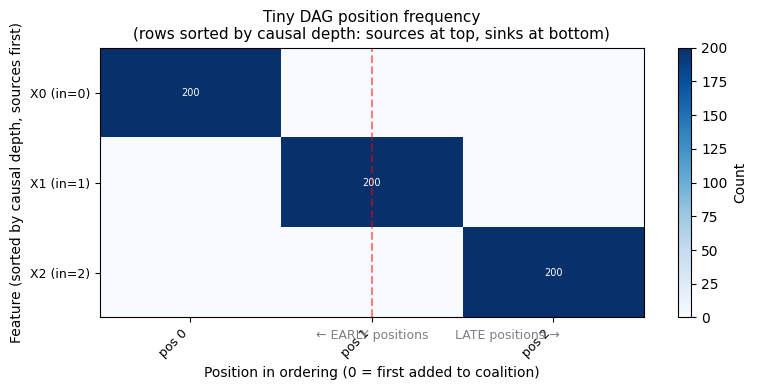


Tiny DAG position frequency — Expected pattern:
  ✅ Correct (source-first): TOP rows (sources) should be HOT on the LEFT side of heatmap
  ❌ Backwards: TOP rows (sources) would be HOT on the RIGHT side

  Source nodes — mass in LEFT half : 200
  Source nodes — mass in RIGHT half: 0
  → Sources appear FIRST (correct causal order)


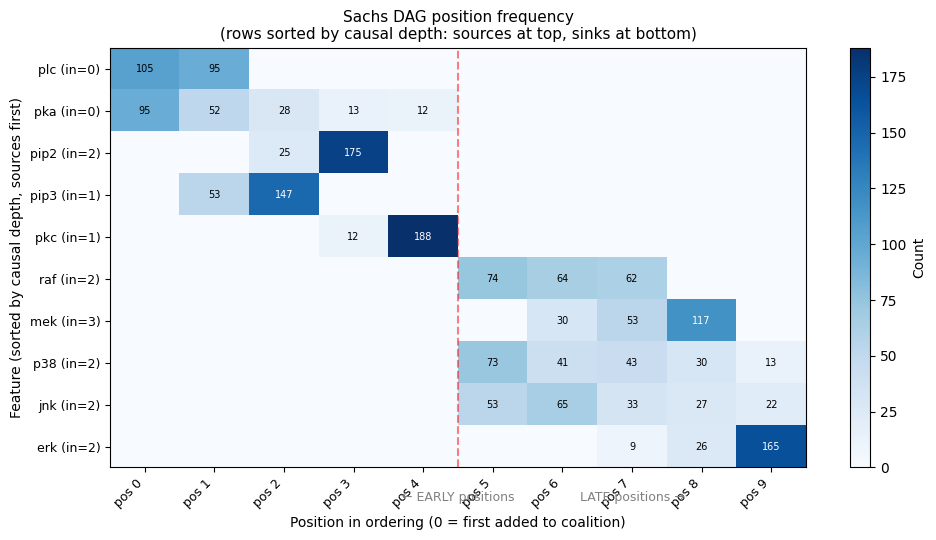


Sachs DAG position frequency — Expected pattern:
  ✅ Correct (source-first): TOP rows (sources) should be HOT on the LEFT side of heatmap
  ❌ Backwards: TOP rows (sources) would be HOT on the RIGHT side

  Source nodes — mass in LEFT half : 400
  Source nodes — mass in RIGHT half: 0
  → Sources appear FIRST (correct causal order)


In [7]:
def plot_position_heatmap(orderings, feature_names, title, adj_x_only=None):
    n = len(feature_names)
    freq = np.zeros((n, n), dtype=int)
    for o in orderings:
        for pos, node in enumerate(o):
            freq[node, pos] += 1

    # Compute expected first/last position based on topological depth
    if adj_x_only is not None:
        G = nx.DiGraph()
        G.add_nodes_from(range(n))
        for i in range(n):
            for j in range(n):
                if adj_x_only[i, j]:
                    G.add_edge(i, j)
        # Longest shortest path from any source as a proxy for topo depth
        sources = [i for i in range(n) if G.in_degree(i) == 0]
        depth = {}
        for src in sources:
            lengths = nx.single_source_shortest_path_length(G, src)
            for node, d in lengths.items():
                depth[node] = max(depth.get(node, 0), d)
        node_order = sorted(range(n), key=lambda i: depth.get(i, 0))
    else:
        node_order = list(range(n))

    freq_ordered = freq[node_order, :]
    labels_ordered = [feature_names[i] for i in node_order]
    in_deg_ordered = [sum(adj_x_only[:, i]) if adj_x_only is not None else 0 for i in node_order]

    fig, ax = plt.subplots(figsize=(max(8, n), max(4, n * 0.55)))
    im = ax.imshow(freq_ordered, aspect="auto", cmap="Blues", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="Count")

    ax.set_xticks(range(n))
    ax.set_xticklabels([f"pos {p}" for p in range(n)], rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(n))
    ax.set_yticklabels(
        [f"{lbl} (in={d})" for lbl, d in zip(labels_ordered, in_deg_ordered)],
        fontsize=9
    )
    ax.set_xlabel("Position in ordering (0 = first added to coalition)", fontsize=10)
    ax.set_ylabel("Feature (sorted by causal depth, sources first)", fontsize=10)
    ax.set_title(f"{title}\n(rows sorted by causal depth: sources at top, sinks at bottom)", fontsize=11)

    # Annotate counts
    for i in range(n):
        for j in range(n):
            v = freq_ordered[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        fontsize=7, color="black" if v < freq_ordered.max() * 0.6 else "white")

    # Vertical line separating "early" vs "late" positions
    ax.axvline(x=n / 2 - 0.5, color="red", lw=1.5, linestyle="--", alpha=0.5)
    ax.text(0.5, -0.08, "← EARLY positions", transform=ax.transAxes,
            ha="center", fontsize=9, color="gray")
    ax.text(0.75, -0.08, "LATE positions →", transform=ax.transAxes,
            ha="center", fontsize=9, color="gray")

    plt.tight_layout()
    plt.show()

    # Quick summary
    print(f"\n{title} — Expected pattern:")
    print("  ✅ Correct (source-first): TOP rows (sources) should be HOT on the LEFT side of heatmap")
    print("  ❌ Backwards: TOP rows (sources) would be HOT on the RIGHT side")
    # Check empirically
    half = n // 2
    source_rows = [i for i, lbl in enumerate(labels_ordered) if in_deg_ordered[i] == 0]
    if source_rows:
        left_mass  = freq_ordered[source_rows, :half].sum()
        right_mass = freq_ordered[source_rows, half:].sum()
        print(f"\n  Source nodes — mass in LEFT half : {left_mass}")
        print(f"  Source nodes — mass in RIGHT half: {right_mass}")
        if left_mass > right_mass:
            print("  → Sources appear FIRST (correct causal order)")
        else:
            print("  → Sources appear LAST (REVERSED — this confirms your hypothesis!)")


# ── Tiny DAG ──────────────────────────────────────────────────────────────────
plot_position_heatmap(tiny_orderings, TINY_FEATURES,
                      "Tiny DAG position frequency", tiny_dag[:3, :3])

# ── Sachs DAG ─────────────────────────────────────────────────────────────────
plot_position_heatmap(sachs_orderings, SACHS_FEATURES,
                      "Sachs DAG position frequency", sachs_adj[:10, :10])